## Comparing the FS and RS AdEx models using Brian2

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

This notebook presents a comparison between two different models: Fast Spiking (FS) and Regular Spiking (RS) *AdEx* models published in [Depannemaecker et al., 2025](https://link.springer.com/article/10.1007/s10827-025-00893-7). 

The classical **AdEx** describes the evolution of the membrane potential $V(t)$ of a single compartment of a neuron membrane. It consists of a system of *two differential equations*:
\begin{align}
    \left\{
    \begin{array}{l}
        C \dfrac{dV}{dt} = -g_{L} (V - E_L) + g_L \Delta_T \exp \left( \dfrac{V - V_\textit{th}}{\Delta_T} \right) - w + I \\
        \tau_w \dfrac{dw}{dt} = a \left( V - E_L \right) - w
    \end{array}
    \right.
\end{align}
When the potential goes beyond ${V}_\textit{th}$, the exponential term generates an upswing of the membrane potential that mimics the exponential activation of $\textrm{\textit{Na}}^+$ channels in a Hodgkin–Huxley-type neuron model, leading to the initiation of an action potential. At a spike detection threshold (e.g. 0 mV), a series of reset conditions is triggered:
\begin{align}
    \left\{
    \begin{array}{l}
        V \rightarrow V_\textit{reset} \\
        w \rightarrow w + b
    \end{array}
    \right.
\end{align}

In this notebook neurons are driven by **current injection**.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import os
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

fig_name = 'Figure_1B'

In [3]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [4]:
from utils.Plots_helper import *

In [5]:
# Path to your JSON file
filename_FS = "extracted_data/FS_f-i_data.json"
filename_RS = "extracted_data/RS_f-i_data.json"
filename_RS_no_adapt = "extracted_data/RS_no_adapt_f-i_data.json"


filenames = [filename_FS, filename_RS, filename_RS_no_adapt]

data_FS = []
data_RS = []
data_RS_no_adapt = []
data = [data_FS, data_RS, data_RS_no_adapt]

amps_FS = []
amps_RS = []
amps_RS_no_adapt = []
amps = [amps_FS, amps_RS, amps_RS_no_adapt]

freqs_FS = []
freqs_RS = []
freqs_RS_no_adapt = []
freqs = [freqs_FS, freqs_RS, freqs_RS_no_adapt]

In [6]:
for i, filename in enumerate(filenames):
    with open(filename, 'r') as f:
        data[i] = json.load(f)

In [7]:
# Extract amp and freq
for i in range(0,3):
    amps[i] = [entry["amp (nA)"] for entry in data[i]]
    freqs[i] = [entry["freq (Hz)"] for entry in data[i]]
    sorted_indices = sorted(range(len(amps[i])), key=lambda k: amps[i][k])
    amps[i] = [amps[i][j] for j in sorted_indices]
    freqs[i] = [freqs[i][j] for j in sorted_indices]

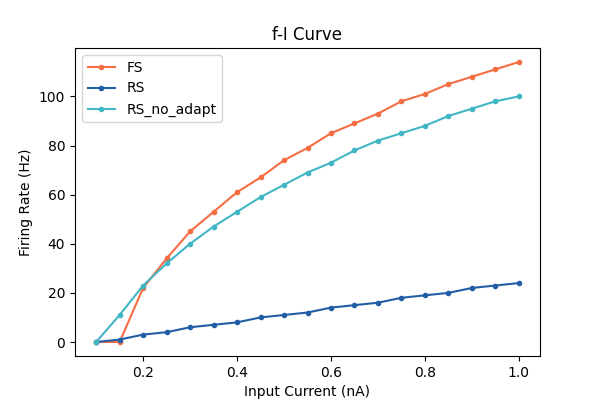

In [8]:
# Plot f-I curve
fig = plt.figure(figsize=(6, 4))
plt.plot(amps[0], freqs[0], marker='o', markersize = 3, color=color_palette['FS'], label='FS')
plt.plot(amps[1], freqs[1], marker='o', markersize = 3, color = color_palette['RS'], label = 'RS')
plt.plot(amps[2], freqs[2], marker='o', markersize = 3, color = color_palette['RS_no_adapt'], label = 'RS_no_adapt')

plt.xlabel("Input Current (nA)")
plt.ylabel("Firing Rate (Hz)")
plt.legend()
plt.title("f-I Curve")
#plt.grid(True)
figs.append(fig)
plt.savefig('figures/f-I_curves_FS-RS.png')

In [9]:
save_figs(fig_path, fig_name, figs)